In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import GradientBoostingClassifier

In [24]:
df = pd.read_csv('diabetes.csv')

In [25]:
df.shape

(768, 9)

In [26]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [28]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- Pregnancies - Right skeweness
- Glucose - Right skeweness
- BloodPressure - Left skeweness
- SkinThickness - Left skewness
- Insulin - Strong right skeweness
- BMI - Right skeweness
- DiabetesPedegreeFunction - Weak right skeweness
- Age - Right skeweness
- Outcome - Right skeweness

In [29]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


There is no values

In [30]:
df.duplicated().sum()

np.int64(0)

There is no duplicate values

In [31]:
df['Outcome'].unique()

array([1, 0])

In [32]:
target = df['Outcome']
features = df.drop(columns=['Outcome'])

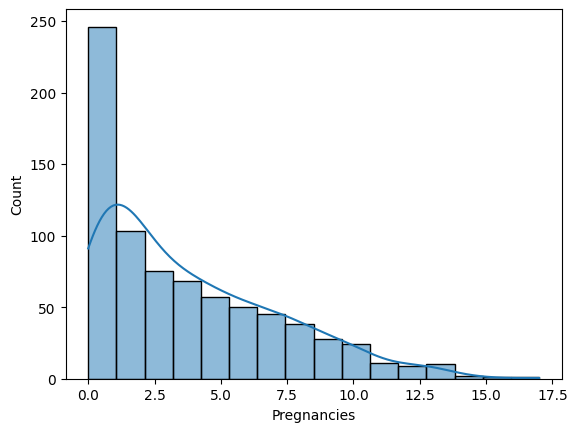

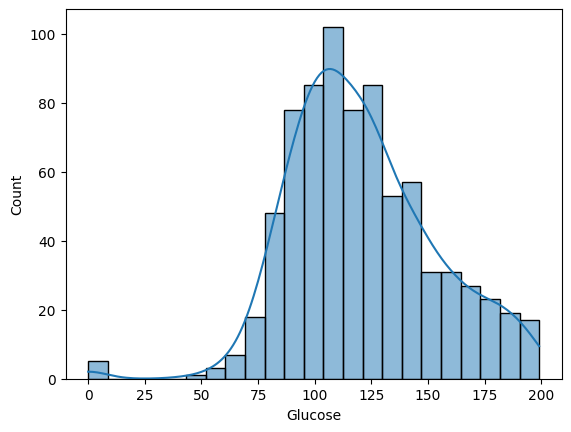

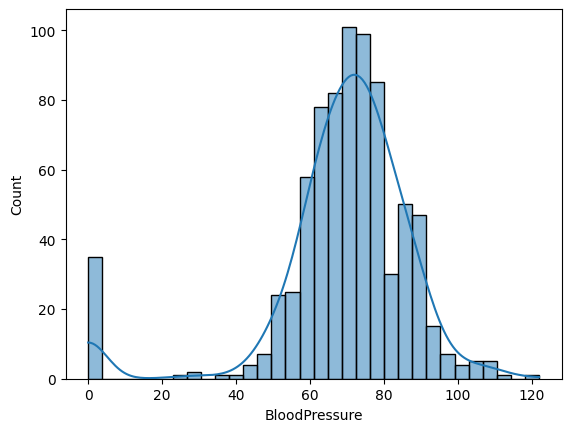

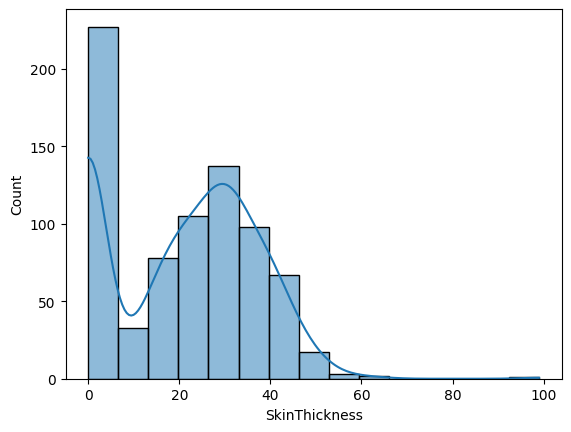

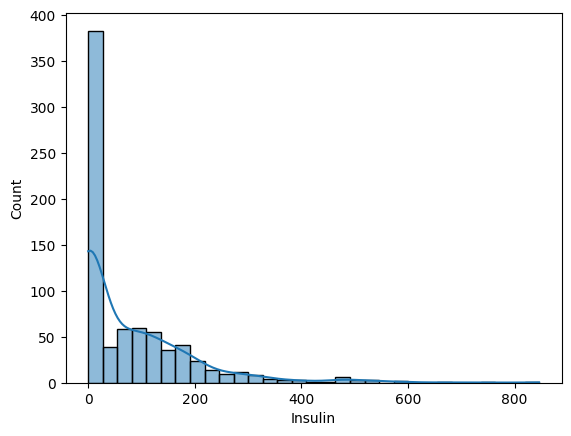

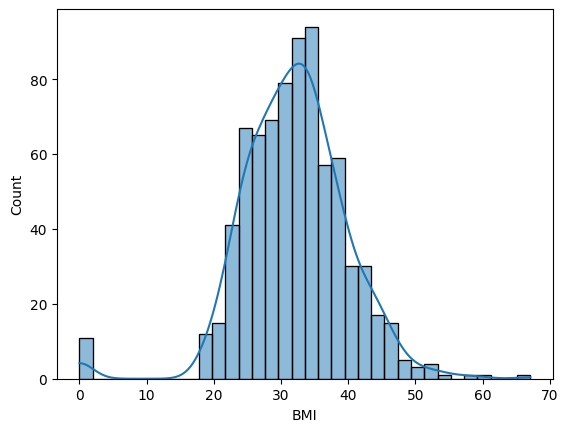

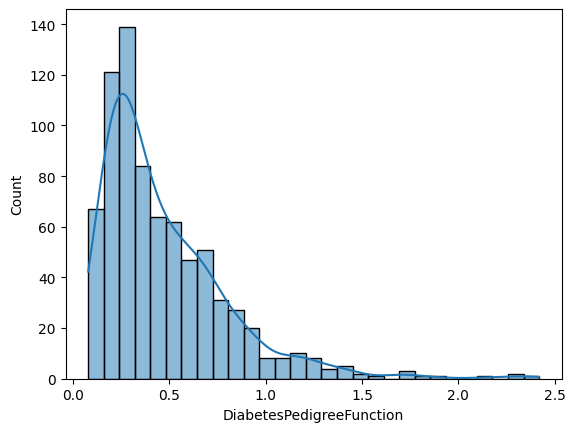

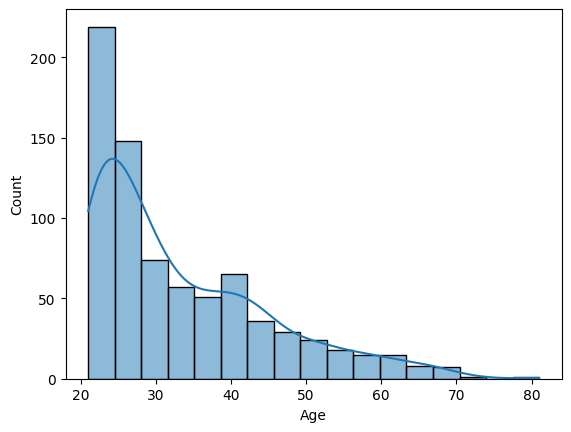

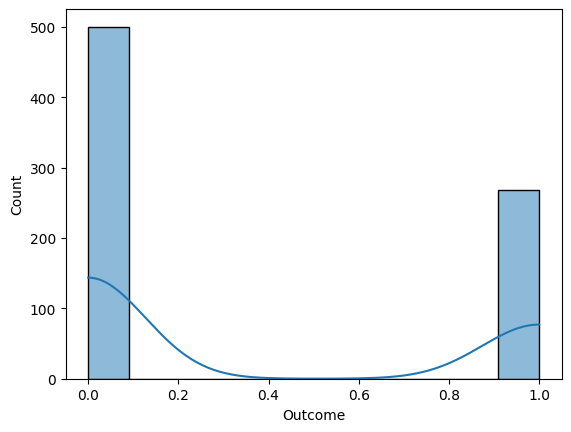

In [33]:
for col in df.columns:
  sns.histplot(df[col],kde= 'True')
  plt.show()

From the histogram we can interpret that,
- Preganancies - Strong right skeweness
- Gluscose - Roughly left skewness
- BloodPressure - Left skewness
- SkinThickness - Bimodal, Two peaks, outliers are on the left side means negative extreme value
- Insulin - Right skewness
- BMI - Roughly left and right skewness , more like approximate normal distribution
- DiabetesPedegreeFunction - Right skewness
- Age - Left skewness
- Outcome - Bimodal because it is a target column, so it have 2 classes.

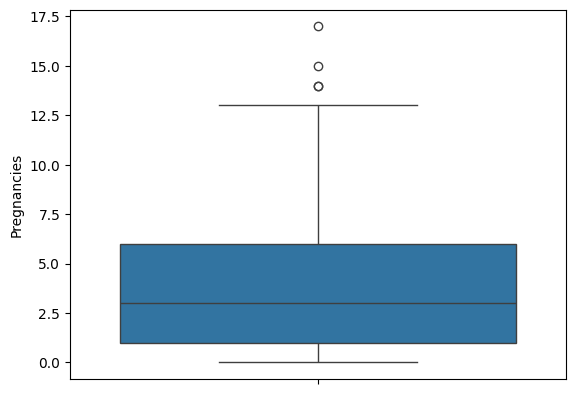

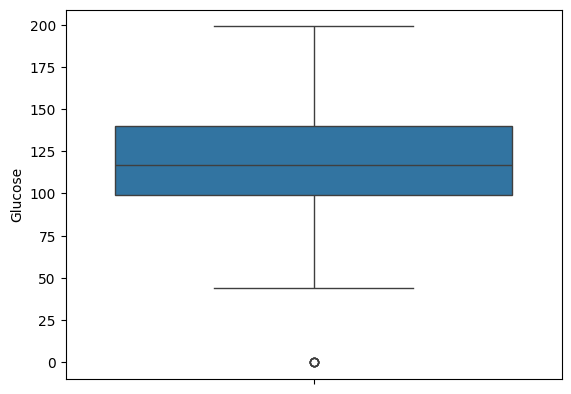

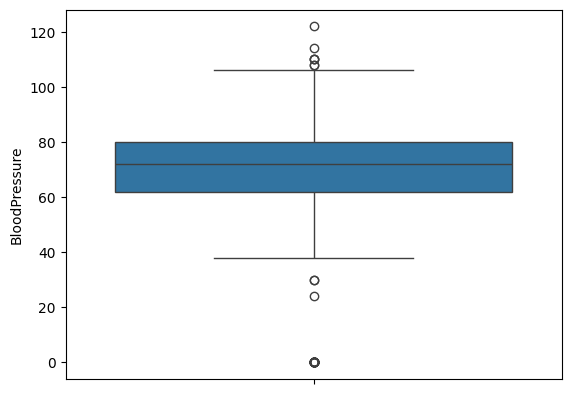

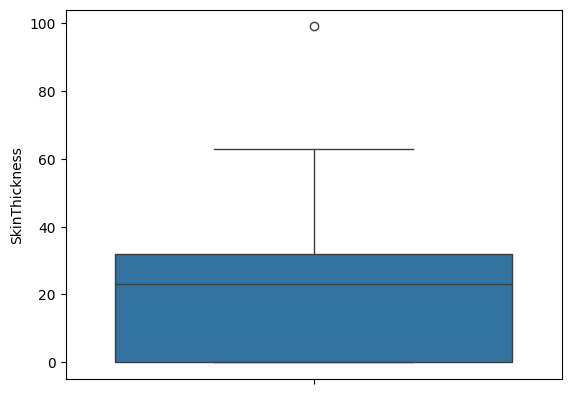

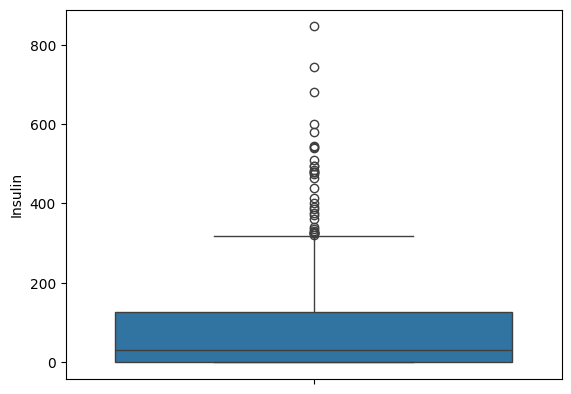

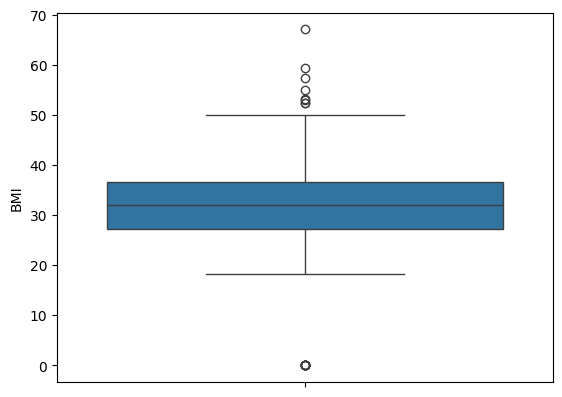

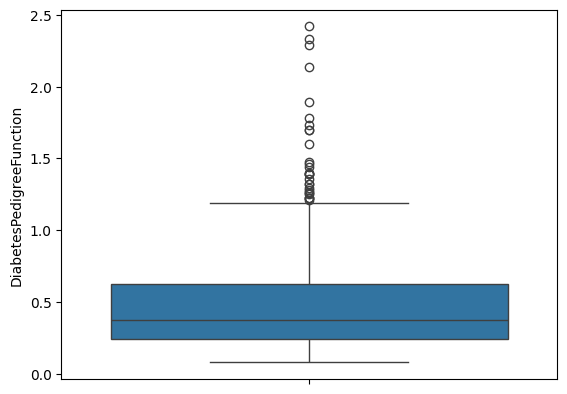

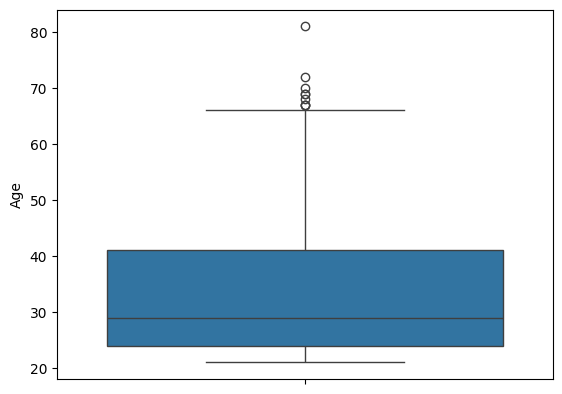

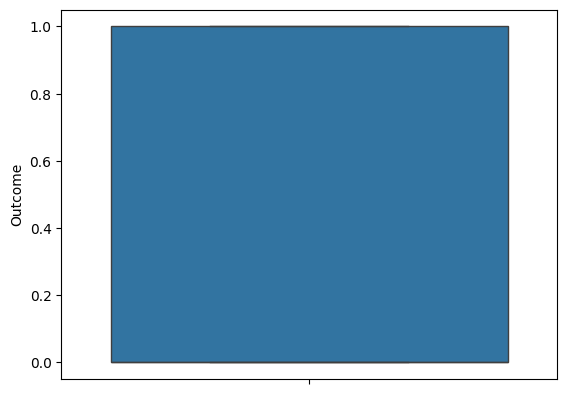

In [34]:
for col in df.columns:
  sns.boxplot(df[col])
  plt.show()

- Every column have outliers except target. Need to apply outlier capping

In [35]:
## Outlier capping
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 -Q1
    lower_extreme = Q1 - 1.5*IQR
    upper_extreme = Q3 + 1.5*IQR
    df[columns] = df[columns].apply(lambda x:lower_extreme if x<lower_extreme else
                                    upper_extreme if x> upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

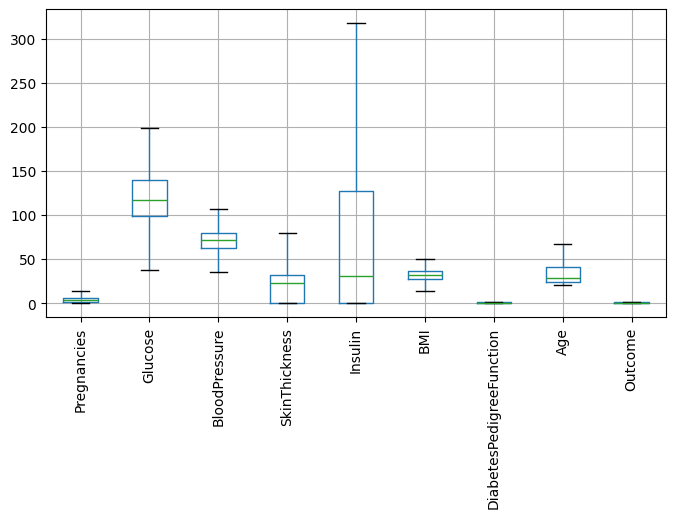

In [36]:
plt.figure(figsize=(8,4))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

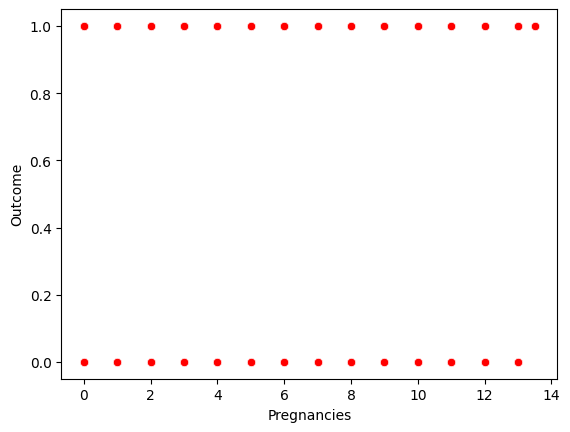

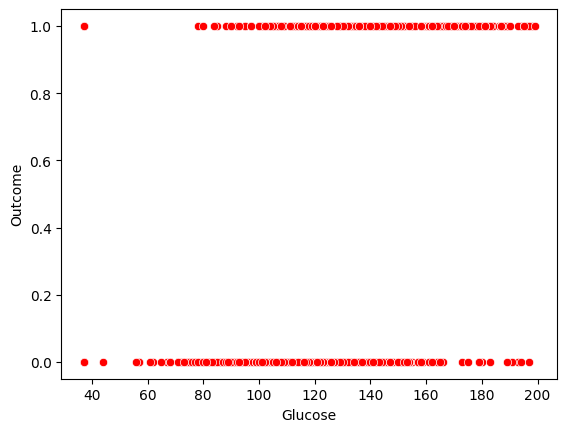

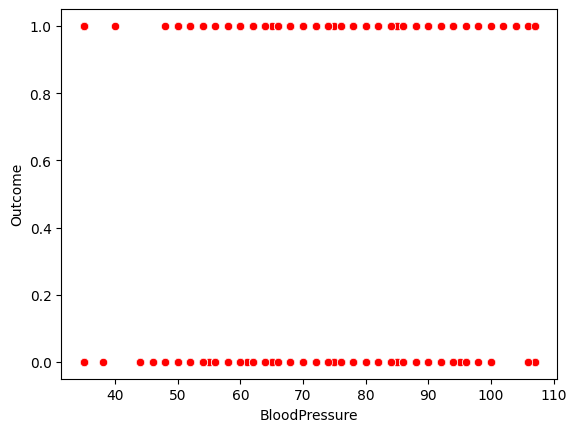

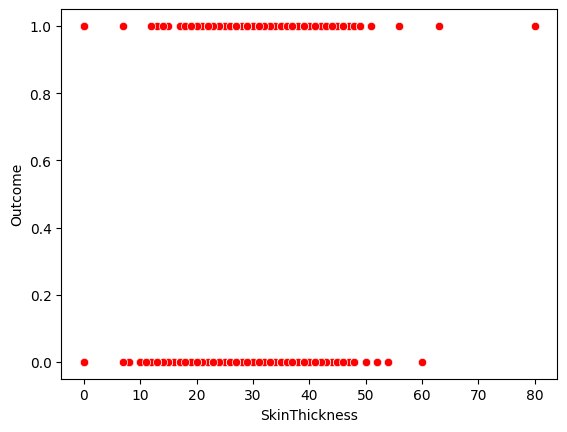

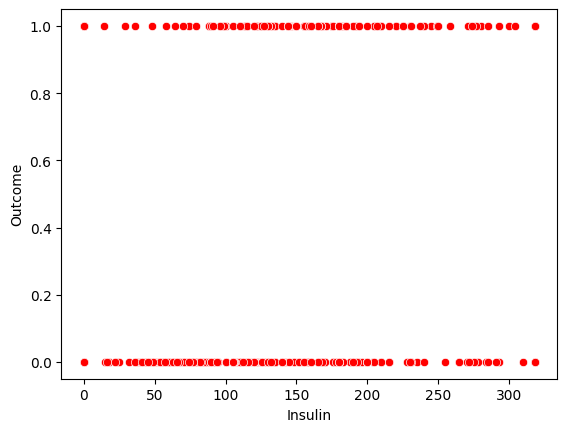

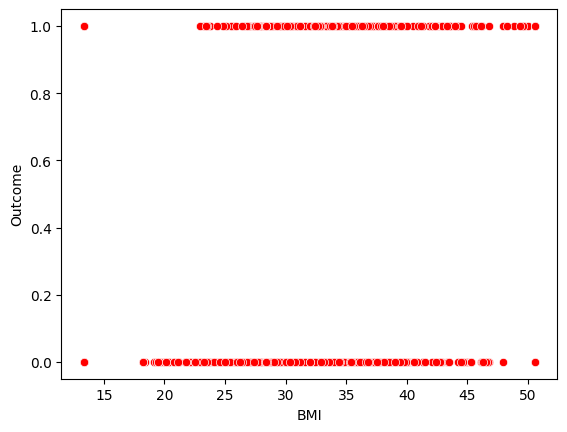

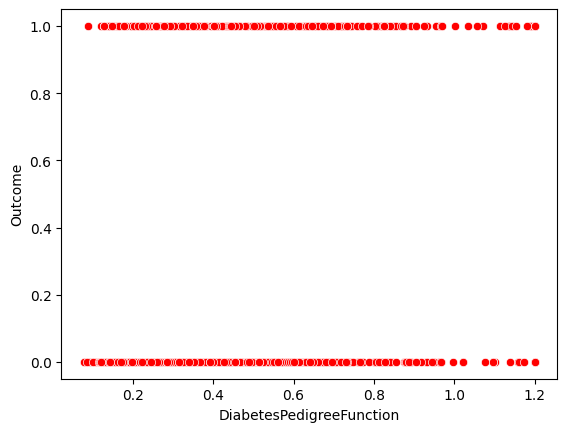

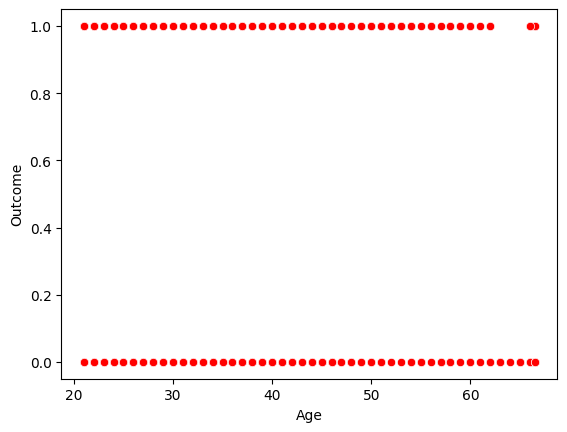

In [38]:
## Scatterplot
for col in df.columns:
  if col != 'Outcome':
    sns.scatterplot(df,x=df[col],y='Outcome',color='red')
    plt.show()

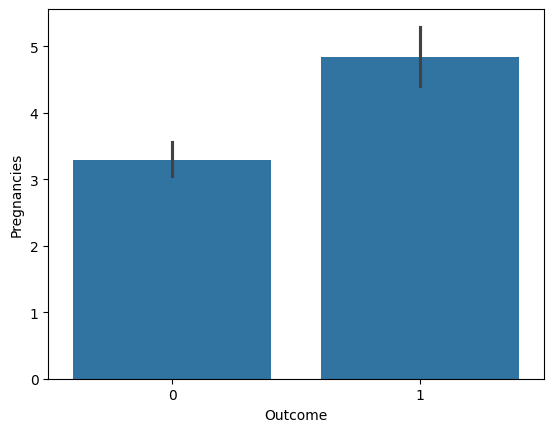

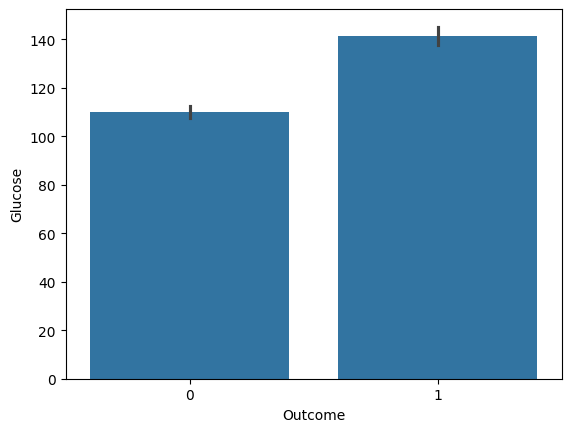

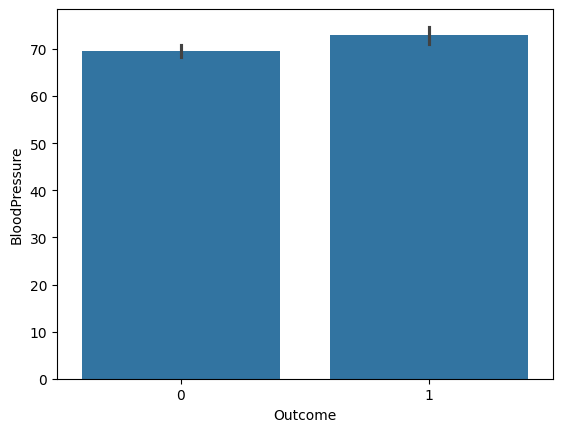

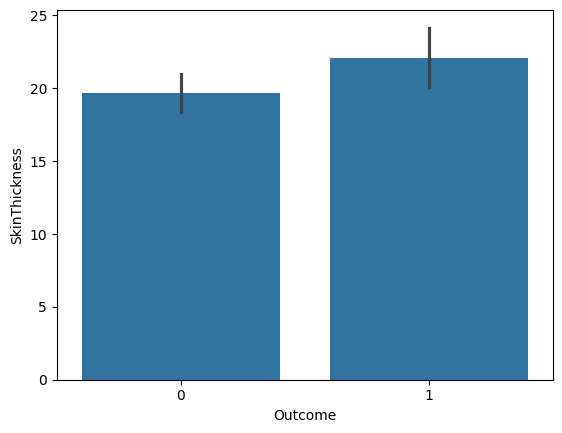

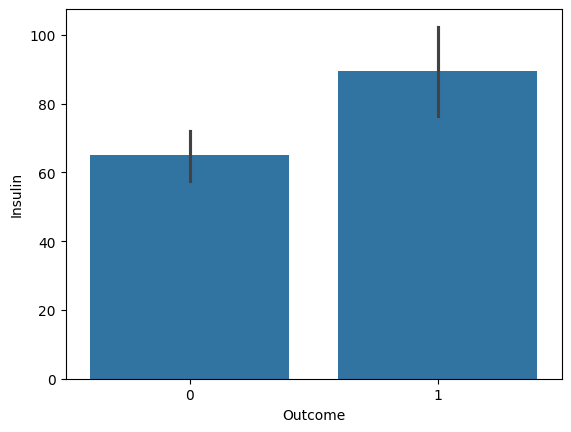

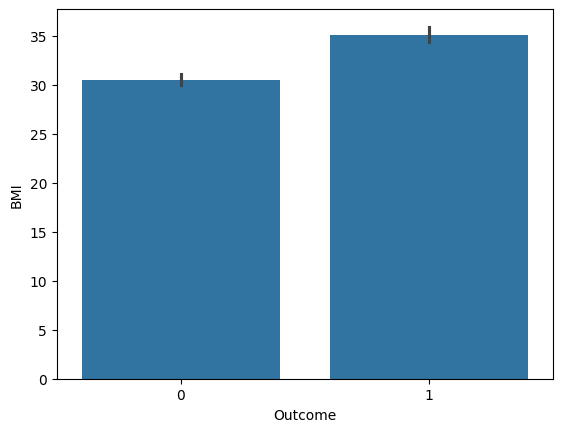

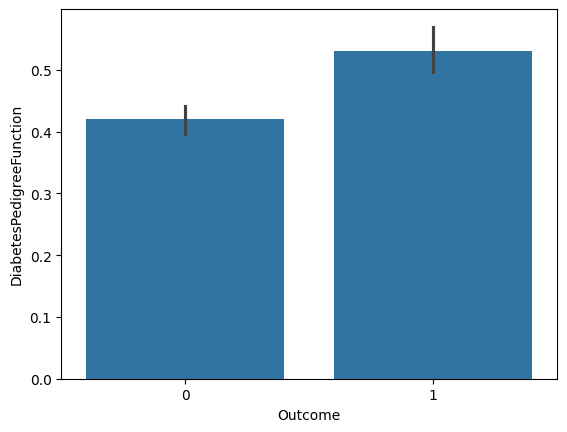

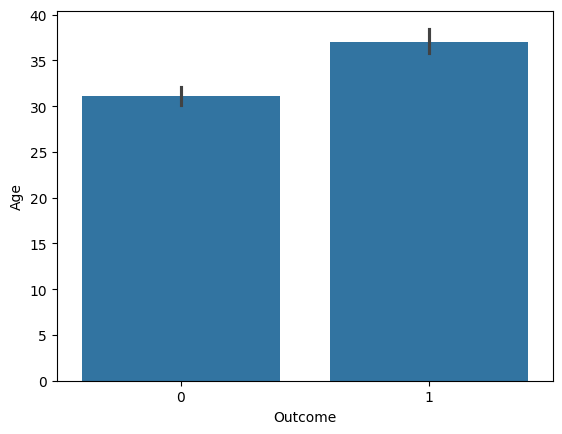

In [41]:
for col in df.columns:
    if col != 'Outcome':
        sns.barplot(x='Outcome', y=col, data=df)
        plt.show()

Because of target is binary the scatterplot and barplot is look like this. Target have only 2 values, and in scatter plot datapoints form 2 groups to indicate that target have 2 classes.
It also applied in barplot

In [42]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


There is no missing values.

In [47]:
df.dtypes

,0
Pregnancies,float64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,float64
Outcome,int64


There is no categorical columns in the dataset

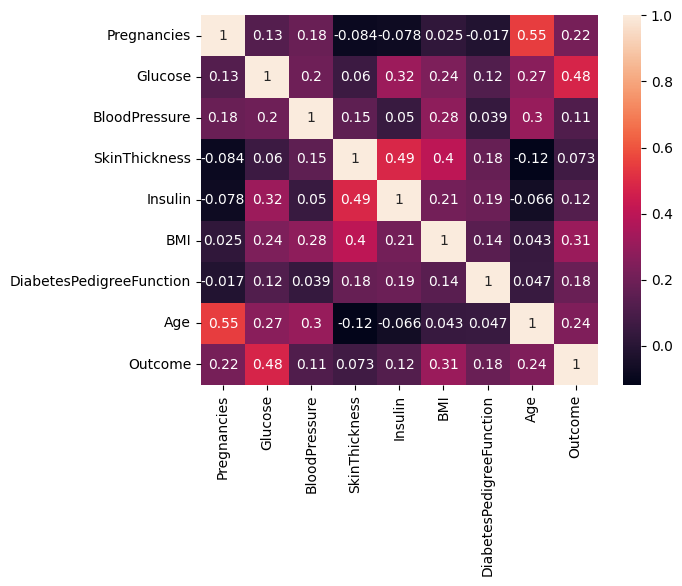

In [48]:
corr = df.corr()
sns.heatmap(corr,annot=True)
plt.show()

The heatmap shows there is no correlation between the columns, except age and pregnancies.
The correlation value of age and pregnancies is small, we can avoid that

In [74]:
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [75]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
660,10,162,84,0,0,27.7,0.182,54
69,4,146,85,27,100,28.9,0.189,27
85,2,110,74,29,125,32.4,0.698,27
219,5,112,66,0,0,37.8,0.261,41
712,10,129,62,36,0,41.2,0.441,38


In [76]:
x_test.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
173,1,79,60,42,48,43.5,0.678,23
253,0,86,68,32,0,35.8,0.238,25
207,5,162,104,0,0,37.7,0.151,52
737,8,65,72,23,0,32.0,0.600,42
191,9,123,70,44,94,33.1,0.374,40


In [77]:
## XGBM

In [78]:
import xgboost as xgb

In [79]:
xgb_model = xgb.XGBClassifier(n_estimators=100,learning_rate=0.5,min_child_weight=2,subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10)

In [80]:
params={'n_estimators':[50,100],'learning_rate':[0.1,0.5]}

In [81]:
xgb_model.fit(x_train,y_train)
y_pred = xgb_model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7077922077922078

In [82]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.81      0.78       101
           1       0.59      0.51      0.55        53

    accuracy                           0.71       154
   macro avg       0.67      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [93]:
## Use gridsearchcv for cross validation

In [94]:
xgb_params = {'n_estimators': [100, 200],'max_depth': [3, 5],'learning_rate': [0.01, 0.1]}

In [95]:
xgb_grid = GridSearchCV(estimator=xgb_model,param_grid=xgb_params,cv=5)
xgb_grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.5, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_features=1, max_leaves=None,
                                     min_child_weight=2, missing=nan,
                                     monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]})

In [97]:
xgb_best = xgb_grid.best_estimator_

In [98]:
y_pred_xgb = xgb_best.predict(x_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81       101
           1       0.64      0.53      0.58        53

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



In [68]:
## LGBM

In [89]:
import lightgbm as lgbm

In [90]:
lgbm_model = lgbm.LGBMClassifier(n_estimator=100,learning_rate=0.1,min_child_weight=1,
                            subsample=0.9,max_features=1,reg_alpha=10,reg_lambda=10,
                            max_bins=10,bundled=True,boosting_type='goss',top_rate=0.2,
                            other_rate=0.3)

In [91]:
lgbm_model.fit(x_train,y_train)
y_pred2 = lgbm_model.predict(x_test)
accuracy_score(y_test,y_pred2)

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 215, number of negative: 399
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 80
[LightG

0.7012987012987013

In [92]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.77      0.78      0.77       101
           1       0.57      0.55      0.56        53

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.67       154
weighted avg       0.70      0.70      0.70       154



In [99]:
## using gridsearchcv for using cross validation

In [123]:
lgbm_params = {'n_estimators': [100, 200,300],'num_leaves': [31, 50],'learning_rate': [0.01,0.05,0.1]}

In [124]:
lgbm_grid = GridSearchCV(estimator=lgbm_model, param_grid=lgbm_params,cv=5,)
lgbm_grid.fit(x_train, y_train)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best ga

GridSearchCV(cv=5,
             estimator=LGBMClassifier(boosting_type='goss', bundled=True,
                                      max_bins=10, max_features=1,
                                      min_child_weight=1, n_estimator=100,
                                      other_rate=0.3, reg_alpha=10,
                                      reg_lambda=10, subsample=0.9,
                                      top_rate=0.2),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'n_estimators': [100, 200, 300],
                         'num_leaves': [31, 50]})

In [125]:
## Best model
lgbm_best = lgbm_grid.best_estimator_

In [126]:
y_pred_lgbm = lgbm_best.predict(x_test)
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: bundled
[LightGBM] [Warning] Unknown parameter: n_estimator
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
              precision    recall  f1-score   support

           0       0.77      0.78      0.77       101
           1       0.57      0.55      0.56        53

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.67       154
weighted avg       0.70      0.70      0.70       154



In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [129]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_prec = precision_score(y_test, y_pred_lgbm)
lgbm_rec = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [xgb_acc, lgbm_acc],
    'Precision': [xgb_prec, lgbm_prec],
    'Recall': [xgb_rec, lgbm_rec],
    'F1 Score': [xgb_f1, lgbm_f1]
})

print(comparison)

      Model  Accuracy  Precision    Recall  F1 Score
0   XGBoost  0.733766   0.636364  0.528302  0.577320
1  LightGBM  0.701299   0.568627  0.547170  0.557692


- XGBoost outperforms LightGBM in terms of accuracy, precision, and F1-score, indicating better overall performance and prediction reliability.
- LightGBM achieves slightly higher recall, making it more effective in identifying diabetic patients.
- Since recall is crucial in medical diagnosis, LightGBM may be preferred when minimizing false negatives is important, whereas XGBoost is better for balanced and overall performance.
